In [1]:
import pandas as pd
df = pd.read_csv('Crop_recommendation.csv')
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [14]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
 8   target       2200 non-null   int64  
dtypes: float64(4), int64(4), str(1)
memory usage: 170.1 KB


,N,P,K,temperature,humidity,ph,rainfall,target
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655,10.500000
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389,6.345731
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267,0.000000
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686,5.000000
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624,10.500000
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508,16.000000
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117,21.000000


In [3]:
df['label'].unique()

<ArrowStringArray>
[       'rice',       'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',
   'mothbeans',    'mungbean',   'blackgram',      'lentil', 'pomegranate',
      'banana',       'mango',      'grapes',  'watermelon',   'muskmelon',
       'apple',      'orange',      'papaya',     'coconut',      'cotton',
        'jute',      'coffee']
Length: 22, dtype: str

In [4]:
print(df['label'].value_counts())

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


In [5]:
crop_summary  = pd.pivot_table(df,index='label',aggfunc='mean')
crop_summary

,K,N,P,humidity,ph,rainfall,temperature
label,,,,,,,
apple,199.89,20.80,134.22,92.333383,5.929663,112.654779,22.630942
banana,50.05,100.23,82.01,80.358123,5.983893,104.626980,27.376798
blackgram,19.24,40.02,67.47,65.118426,7.133952,67.884151,29.973340
chickpea,79.92,40.09,67.79,16.860439,7.336957,80.058977,18.872847
coconut,30.59,21.98,16.93,94.844272,5.976562,175.686646,27.409892
coffee,29.94,101.20,28.74,58.869846,6.790308,158.066295,25.540477
cotton,19.56,117.77,46.24,79.843474,6.912675,80.398043,23.988958
grapes,200.11,23.18,132.53,81.875228,6.025937,69.611829,23.849575
jute,39.99,78.40,46.86,79.639864,6.732778,174.792798,24.958376


In [6]:
from sklearn.preprocessing import LabelEncoder 
le =LabelEncoder()
df['target'] = le.fit_transform(df['label'])
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label,target
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,20


In [7]:
#Tracking the encoded
label_mapping_crop =dict(zip(le.classes_,le.transform(le.classes_)))
print(label_mapping_crop)

{'apple': np.int64(0), 'banana': np.int64(1), 'blackgram': np.int64(2), 'chickpea': np.int64(3), 'coconut': np.int64(4), 'coffee': np.int64(5), 'cotton': np.int64(6), 'grapes': np.int64(7), 'jute': np.int64(8), 'kidneybeans': np.int64(9), 'lentil': np.int64(10), 'maize': np.int64(11), 'mango': np.int64(12), 'mothbeans': np.int64(13), 'mungbean': np.int64(14), 'muskmelon': np.int64(15), 'orange': np.int64(16), 'papaya': np.int64(17), 'pigeonpeas': np.int64(18), 'pomegranate': np.int64(19), 'rice': np.int64(20), 'watermelon': np.int64(21)}


In [15]:
x = df.drop(['label','target'],axis=1)
y = df['target']

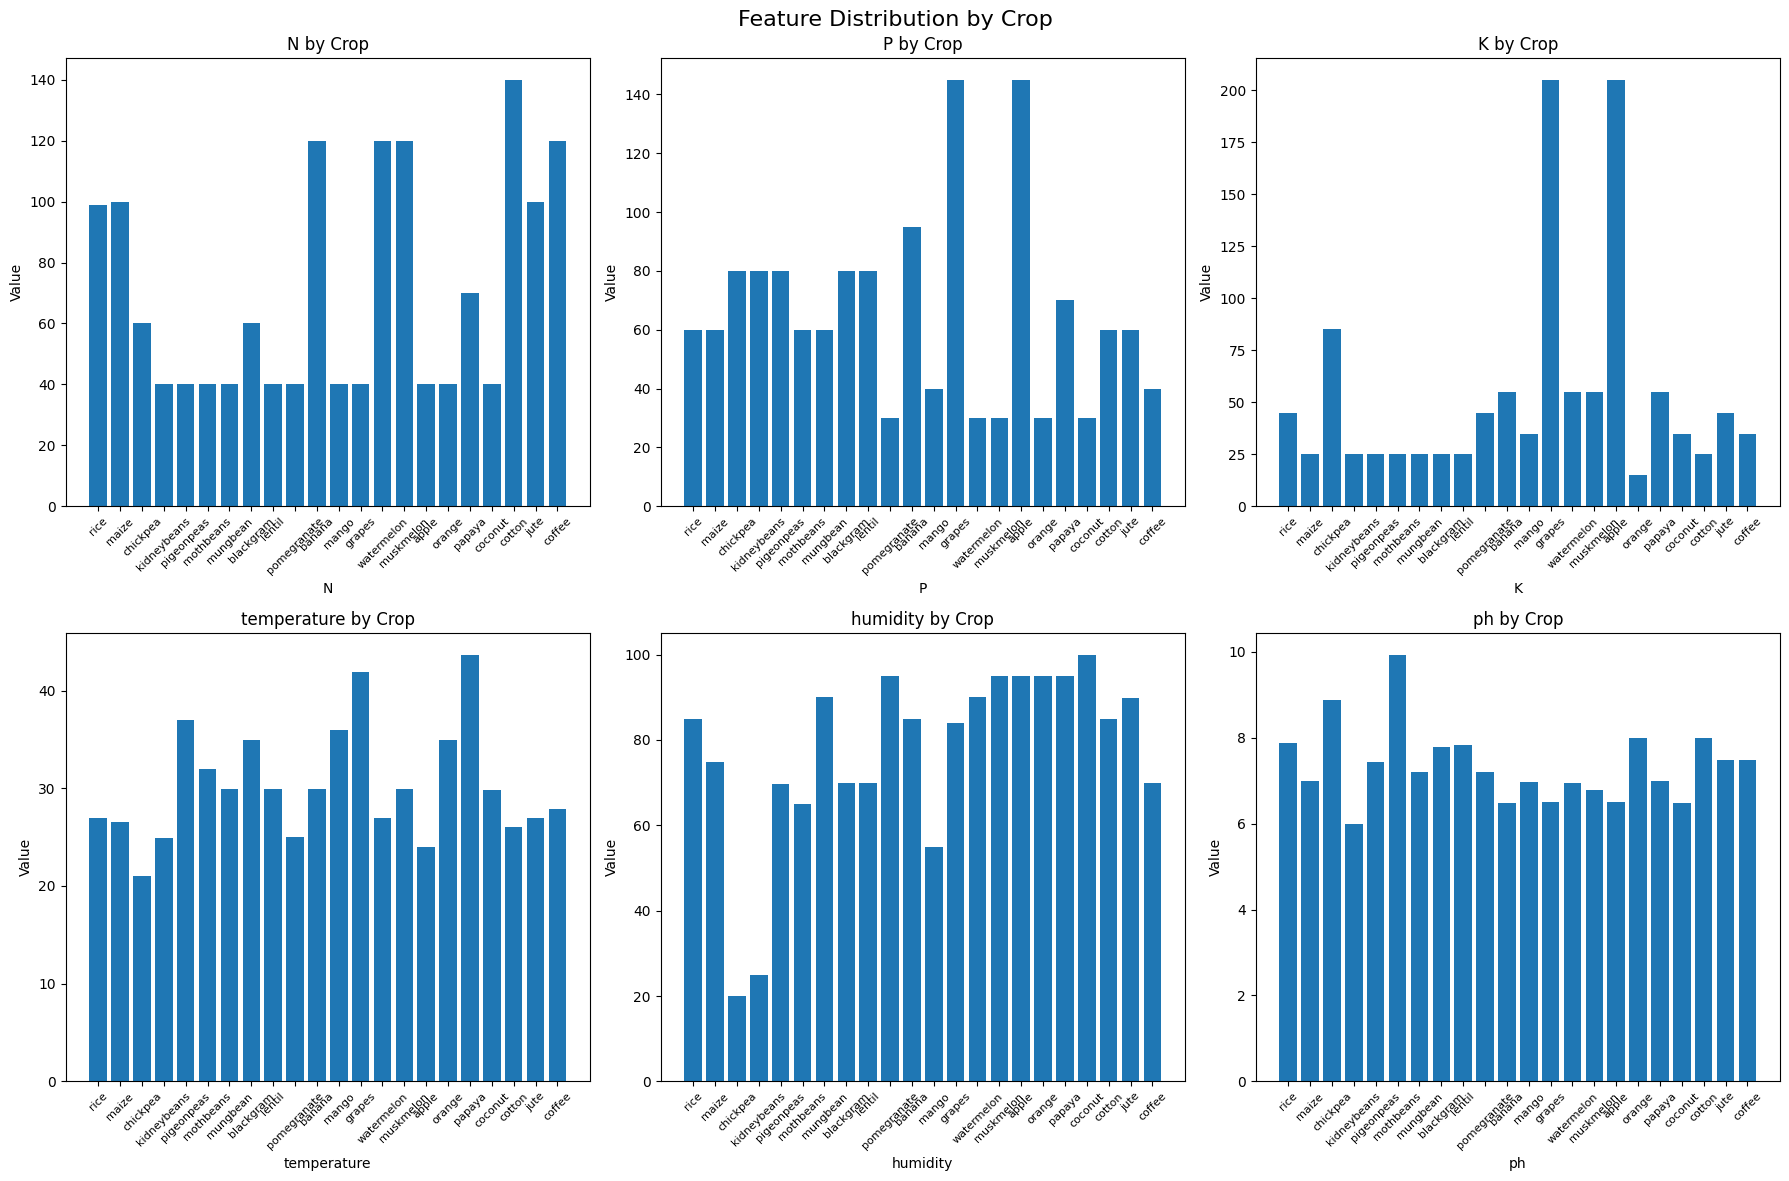

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3 ,figsize=(18, 12))  
fig.suptitle('Feature Distribution by Crop', fontsize=16)

axes = axes.flatten()  

for i, feature in enumerate(x.columns[:6]):  
    axes[i].bar(df['label'], x[feature])
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Value')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    axes[i].set_title(f'{feature} by Crop')



plt.tight_layout()
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

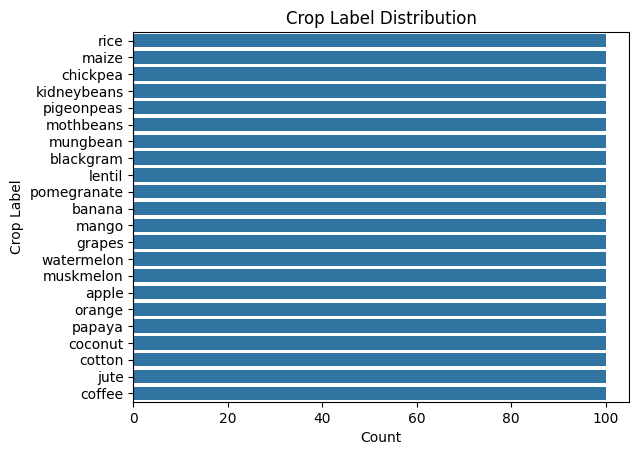

In [12]:

sns.countplot(data=df, y='label', order=df['label'].value_counts().index)

plt.title('Crop Label Distribution')
plt.xlabel('Count')
plt.ylabel('Crop Label')
plt.show

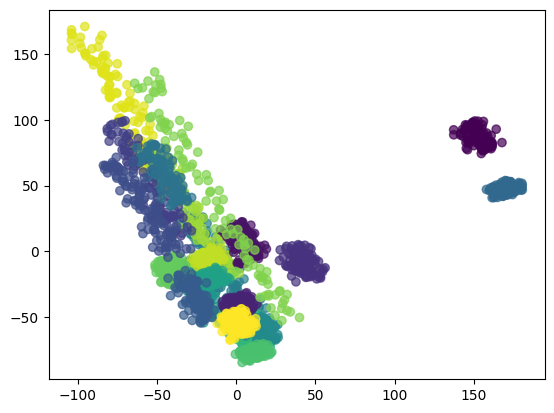

In [21]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)
plt.scatter(x_pca[:, 0], x_pca[:, 1],c=y, alpha=0.7)
plt.show()

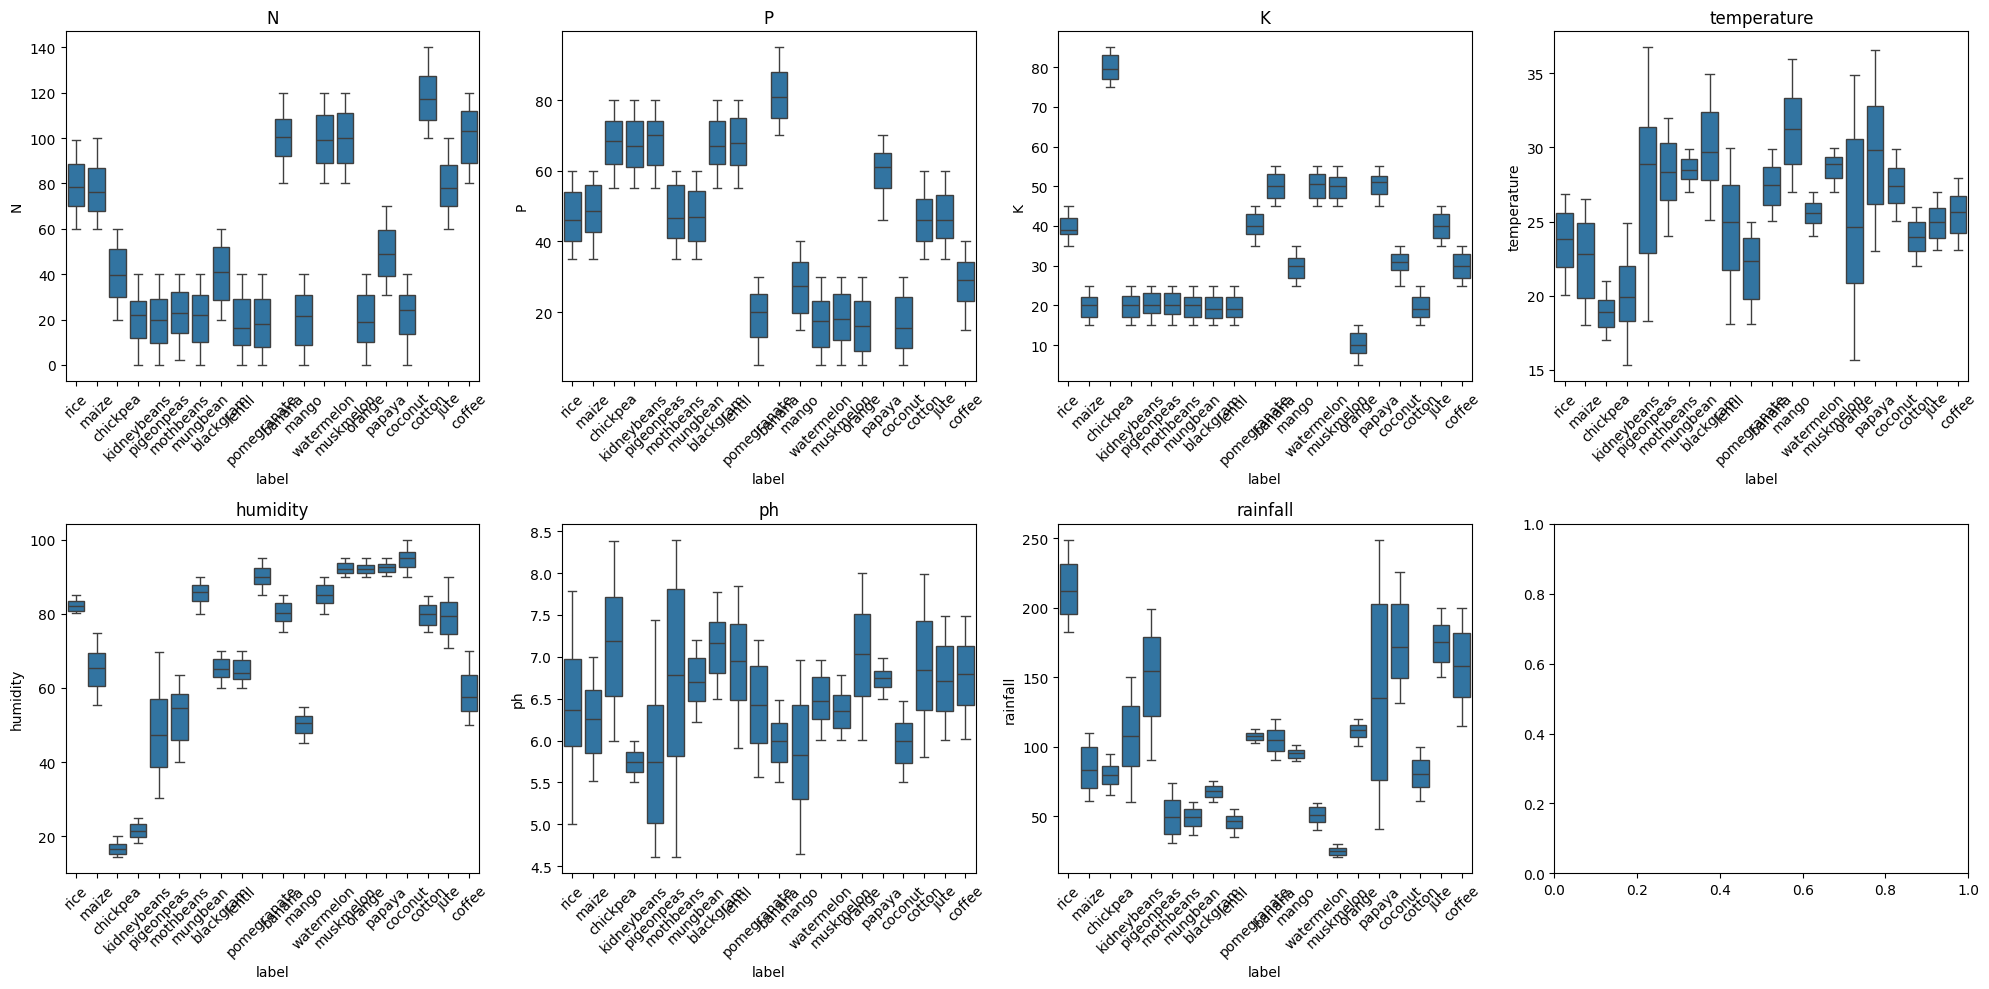

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feature in enumerate(x.columns):  # x = df.drop('label', axis=1)
    sns.boxplot(data=df, x='label', y=feature, ax=axes[i])
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

In [25]:
x.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'], dtype='object')

In [22]:
def Remove_outlier_iqr(df,col):
    q1 = df[col].quantile(0.25)
    q3= df[col].quantile(0.75)
    IQR = q3 - q1
    lower = q1 - 1.5*IQR
    upper = q3 + 1.5 *IQR

    df = df[(df[col]>=lower) & (df[col]<=upper)]
    return df


for i in x.columns:
    df = Remove_outlier_iqr(df, i)
df.shape

(1772, 9)

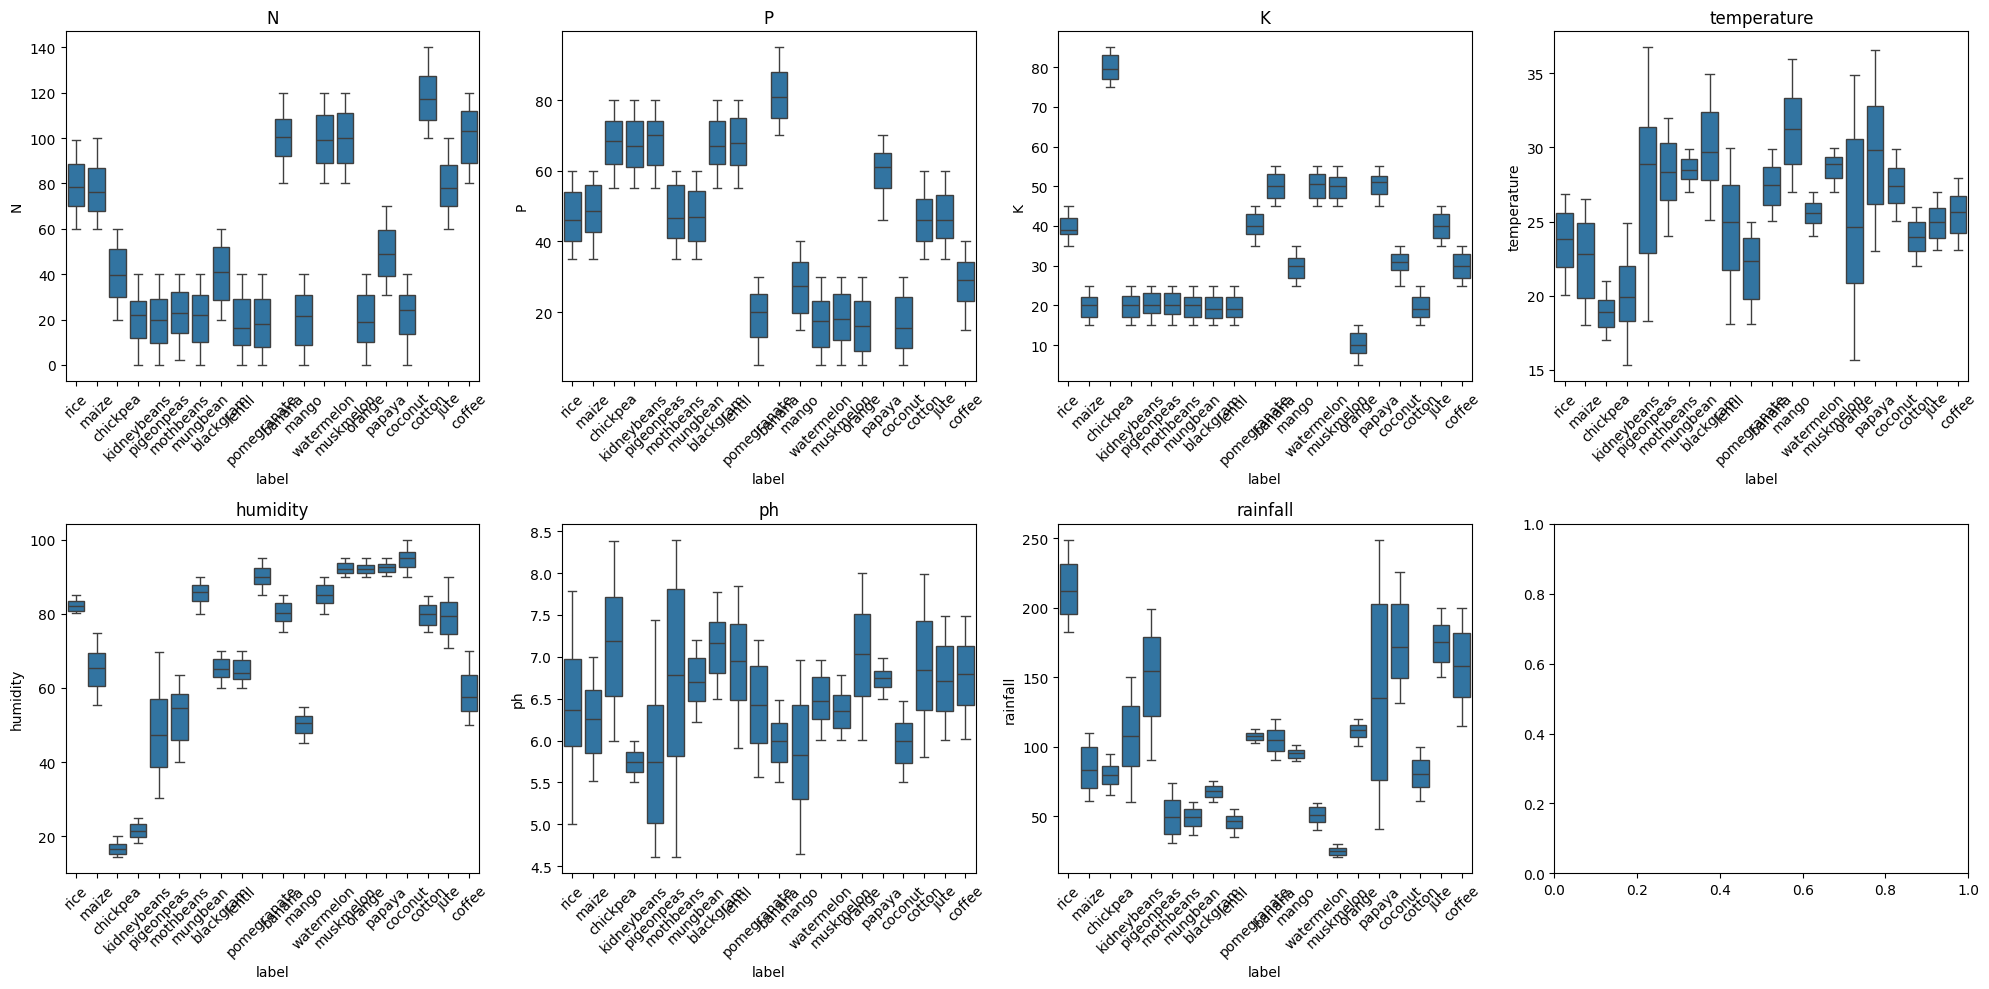

In [27]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feature in enumerate(x.columns):  # x = df.drop('label', axis=1)
    sns.boxplot(data=df, x='label', y=feature, ax=axes[i])
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

In [28]:
from sklearn.model_selection import train_test_split
x = df.drop(['label','target'],axis=1)
y = df['target']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

model_logistic = Pipeline([
    ('scale',StandardScaler()),
    ('model',LogisticRegression())
])
parm_grid = {
    'model__C': [0.1,1,10],
    'model__penalty':['l2'],
    'model__solver': ['lbfgs']
}
grid = GridSearchCV(estimator=model_logistic,param_grid=parm_grid,cv=5,scoring='accuracy',n_jobs=-1)
grid.fit(x_train,y_train)

,estimator,Pipeline(step...egression())])
,param_grid,"{'model__C': [0.1, 1, ...], 'model__penalty': ['l2'], 'model__solver': ['lbfgs']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [30]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

y_predit = grid.predict(x_test)
print(confusion_matrix(y_test,y_predit))
print(classification_report(y_test,y_predit))

[[22  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 27  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  1  0  9  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 23  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 18  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 13  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 11  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 24  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 25  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 22  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 14  0  0

In [31]:
import joblib
joblib.dump(grid,'crop_model.plk')
joblib.dump(le,'crop_encode.plk')


['crop_encode.plk']

In [32]:
y_predit = grid.predict([[1,20,40,6,7,10,15]])
le.inverse_transform([y_predit[0]])[0]

C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


'mothbeans'